# 02 - Preparacao de Dados

Limpeza, filtros por percentil e feature engineering em Spark SQL puro. Saida materializada em Parquet particionado por mes para uso pelos notebooks de modelagem.


In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

from _lib import build_spark, DATA_GLOB, LOOKUP_PATH, CLEAN_DATA_PATH, BOUNDS_PATH

spark = build_spark('nyc-rideshare-preprocessing')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style='whitegrid')


In [2]:
spark.read.parquet(DATA_GLOB).createOrReplaceTempView('trips_full')
(spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(LOOKUP_PATH)
    .createOrReplaceTempView('taxi_zone_lookup'))

# Recorte temporal: Mar-Ago 2023 (6 meses). O arquivo cobre Dez/2021-Ago/2023.
# Filtro aqui evita OOM nos workers (4G cada) e garante que o SPLIT_DATE=2023-06-01
# tenha 3 meses de treino e 3 de teste conforme CLAUDE.md.
spark.sql("""
    CREATE OR REPLACE TEMPORARY VIEW trips_raw AS
    SELECT * FROM trips_full
    WHERE date >= '2023-03-01'
      AND date <  '2023-09-01'
""")

spark.sql('SELECT COUNT(*) AS raw_rows FROM trips_raw').show()


+---------+
| raw_rows|
+---------+
|116225448|
+---------+



In [3]:
# Bounds por percentil 0.1% e 99.9% para os filtros da limpeza.
# speed = trip_length / (total_ride_time / 3600)  [mph]
spark.sql("""
CREATE OR REPLACE TEMPORARY VIEW cleaning_bounds AS
WITH fare_bounds AS (
    SELECT
        PERCENTILE_APPROX(passenger_fare, 0.001) AS fare_low,
        PERCENTILE_APPROX(passenger_fare, 0.999) AS fare_high
    FROM trips_raw
    WHERE passenger_fare > 0
),
speed_bounds AS (
    SELECT
        PERCENTILE_APPROX(trip_length / (total_ride_time / 3600.0), 0.001) AS speed_low,
        PERCENTILE_APPROX(trip_length / (total_ride_time / 3600.0), 0.999) AS speed_high
    FROM trips_raw
    WHERE trip_length > 0
      AND total_ride_time > 60
)
SELECT * FROM fare_bounds CROSS JOIN speed_bounds
""")

import json as _json
bounds_row = spark.sql('SELECT * FROM cleaning_bounds').collect()[0].asDict()
BOUNDS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(BOUNDS_PATH, 'w') as fh:
    _json.dump({k: float(v) for k, v in bounds_row.items()}, fh, indent=2)
print(f'Bounds: {bounds_row}')
spark.sql('SELECT * FROM cleaning_bounds').show(truncate=False)


Bounds: {'fare_low': 6.0, 'fare_high': 232.10999999999999, 'speed_low': 2.337662337662338, 'speed_high': 47.23473541383989}


+--------+------------------+------------------+-----------------+
|fare_low|fare_high         |speed_low         |speed_high       |
+--------+------------------+------------------+-----------------+
|6.0     |232.10999999999999|2.3688311688311687|47.23473541383989|
+--------+------------------+------------------+-----------------+



In [4]:
# Auditoria de qualidade: contar linhas com cada problema antes do filtro
spark.sql("""
WITH base AS (
    SELECT *,
        trip_length / (total_ride_time / 3600.0) AS speed_mph_raw
    FROM trips_raw
),
cb AS (SELECT * FROM cleaning_bounds)
SELECT
    COUNT(*) AS total_raw,
    SUM(CASE WHEN passenger_fare <= 0 OR passenger_fare IS NULL THEN 1 ELSE 0 END) AS invalid_fare,
    SUM(CASE WHEN trip_length <= 0 THEN 1 ELSE 0 END) AS invalid_miles,
    SUM(CASE WHEN total_ride_time < 60 THEN 1 ELSE 0 END) AS too_short,
    SUM(CASE WHEN pickup_location IN (264, 265) OR dropoff_location IN (264, 265) THEN 1 ELSE 0 END) AS invalid_zones,
    SUM(CASE WHEN request_to_pickup < 0 THEN 1 ELSE 0 END) AS negative_wait
FROM base CROSS JOIN cb
""").show()


+---------+------------+-------------+---------+-------------+-------------+
|total_raw|invalid_fare|invalid_miles|too_short|invalid_zones|negative_wait|
+---------+------------+-------------+---------+-------------+-------------+
|116225448|       39628|        19596|    10925|      4806254|      1061782|
+---------+------------+-------------+---------+-------------+-------------+



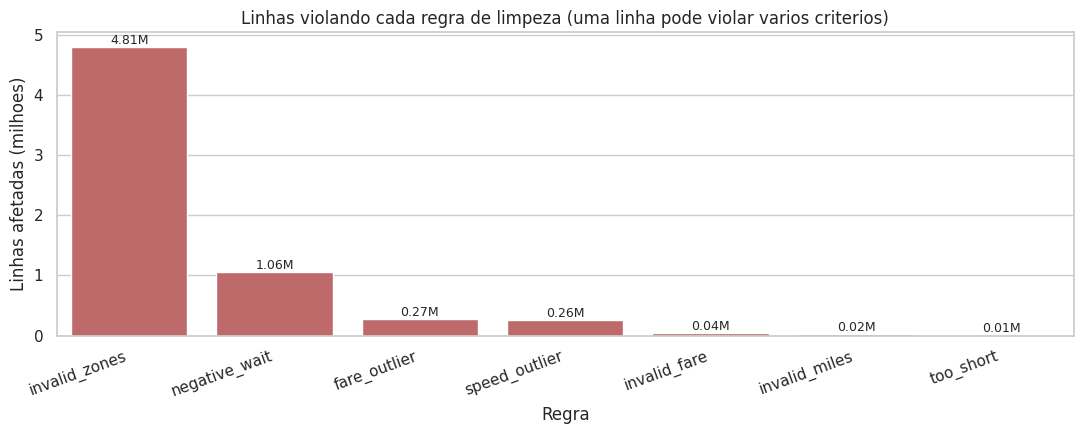

In [5]:

# Visualiza as linhas removidas por cada criterio (a violacao pode estar em mais de um criterio simultaneamente)
audit_pdf = spark.sql("""
WITH base AS (
    SELECT *,
        trip_length / (total_ride_time / 3600.0) AS speed_mph_raw
    FROM trips_raw
), cb AS (SELECT * FROM cleaning_bounds)
SELECT
    SUM(CASE WHEN passenger_fare <= 0 OR passenger_fare IS NULL THEN 1 ELSE 0 END) AS invalid_fare,
    SUM(CASE WHEN trip_length <= 0 THEN 1 ELSE 0 END) AS invalid_miles,
    SUM(CASE WHEN total_ride_time < 60 THEN 1 ELSE 0 END) AS too_short,
    SUM(CASE WHEN pickup_location IN (264, 265) OR dropoff_location IN (264, 265) THEN 1 ELSE 0 END) AS invalid_zones,
    SUM(CASE WHEN request_to_pickup < 0 THEN 1 ELSE 0 END) AS negative_wait,
    SUM(CASE WHEN passenger_fare NOT BETWEEN cb.fare_low AND cb.fare_high THEN 1 ELSE 0 END) AS fare_outlier,
    SUM(CASE WHEN speed_mph_raw NOT BETWEEN cb.speed_low AND cb.speed_high THEN 1 ELSE 0 END) AS speed_outlier
FROM base CROSS JOIN cb
""").toPandas().T.reset_index()
audit_pdf.columns = ['rule', 'rows']
audit_pdf['rows_M'] = audit_pdf['rows'] / 1e6
audit_pdf = audit_pdf.sort_values('rows', ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=audit_pdf, x='rule', y='rows_M', ax=ax, color='indianred')
for i, row in enumerate(audit_pdf.itertuples()):
    ax.text(i, row.rows_M, f'{row.rows_M:,.2f}M', ha='center', va='bottom', fontsize=9)
ax.set_title('Linhas violando cada regra de limpeza (uma linha pode violar varios criterios)')
ax.set_xlabel('Regra')
ax.set_ylabel('Linhas afetadas (milhoes)')
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
plt.show()


In [6]:
# Limpeza por percentil + feature engineering
# Excluidos: driver_total_pay (regulatorio), rideshare_profit (derivado do target),
#            hourly_rate e dollars_per_mile (LEAKAGE: computados a partir de passenger_fare),
#            on_scene_to_pickup / on_scene_to_dropoff (cobertura desigual entre operadoras)
spark.sql("""
CREATE OR REPLACE TEMPORARY VIEW trips_clean AS
WITH base AS (
    SELECT
        b.*,
        trip_length / (total_ride_time / 3600.0) AS speed_mph,
        pu_zone.Borough AS pu_borough,
        do_zone.Borough AS do_borough
    FROM trips_raw b
    LEFT JOIN taxi_zone_lookup pu_zone ON b.pickup_location  = pu_zone.LocationID
    LEFT JOIN taxi_zone_lookup do_zone ON b.dropoff_location = do_zone.LocationID
)
SELECT
    business,
    pickup_location,
    dropoff_location,
    trip_length,
    total_ride_time,
    request_to_pickup,
    passenger_fare,
    hour_of_day,
    month_of_year,
    week_of_year,
    time_of_day,
    date,
    pu_borough,
    do_borough,
    speed_mph,
    DAYOFWEEK(date)  AS pickup_dow,
    CASE WHEN DAYOFWEEK(date) IN (1, 7) THEN 1 ELSE 0 END AS is_weekend,
    CASE WHEN hour_of_day BETWEEN 7 AND 9 OR hour_of_day BETWEEN 16 AND 19 THEN 1 ELSE 0 END AS is_rush_hour,
    CASE WHEN hour_of_day >= 22 OR hour_of_day <= 4 THEN 1 ELSE 0 END AS is_late_night,
    CASE WHEN pickup_location  IN (1, 132, 138) THEN 1 ELSE 0 END AS pickup_airport,
    CASE WHEN dropoff_location IN (1, 132, 138) THEN 1 ELSE 0 END AS dropoff_airport,
    -- NULL-safe: zona desconhecida -> 0
    CASE
        WHEN pu_borough IS NULL OR do_borough IS NULL THEN 0
        WHEN pu_borough = do_borough THEN 1
        ELSE 0
    END AS same_borough,
    DATE_FORMAT(date, 'yyyy-MM') AS pickup_year_month
FROM base
CROSS JOIN cleaning_bounds cb
WHERE passenger_fare BETWEEN cb.fare_low AND cb.fare_high   -- percentil 0.1% - 99.9%
  AND trip_length > 0                                        -- distancia positiva
  AND total_ride_time BETWEEN 60 AND 14400                   -- 1 min a 4 h
  AND request_to_pickup >= 0                                 -- espera nao negativa
  AND speed_mph BETWEEN cb.speed_low AND cb.speed_high      -- percentil velocidade
  AND speed_mph > 0.5                                        -- piso anti-ruido
  AND pickup_location  NOT IN (264, 265)                    -- Unknown / Outside NYC
  AND dropoff_location NOT IN (264, 265)
""")

spark.sql('SELECT COUNT(*) AS clean_rows FROM trips_clean').show()


+----------+
|clean_rows|
+----------+
| 110116813|
+----------+



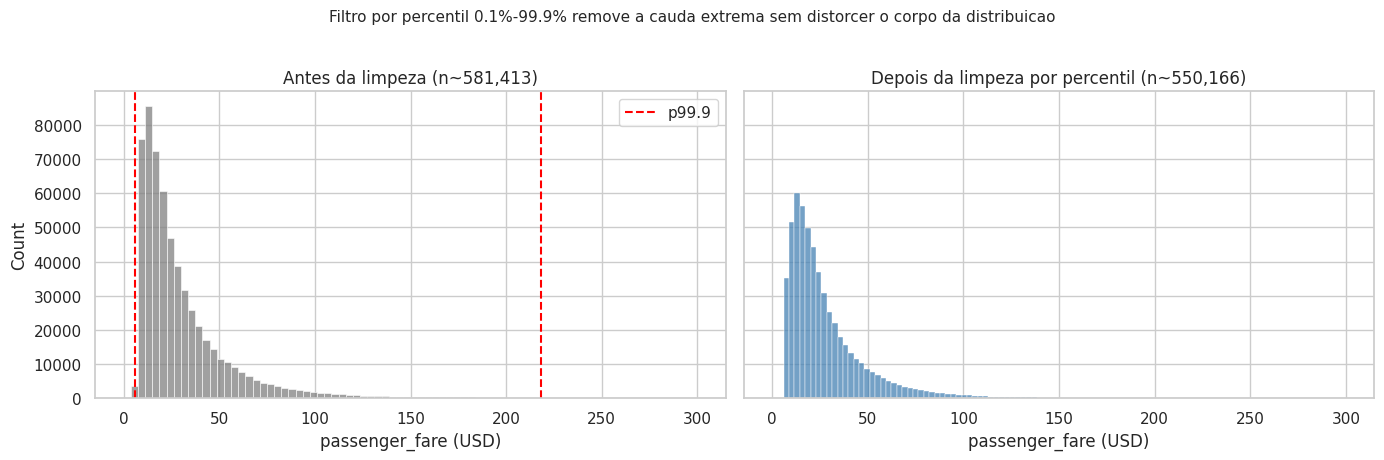

In [7]:

# Distribuicao da tarifa antes e depois da limpeza por percentil
before_pdf = spark.sql("""
SELECT passenger_fare FROM trips_raw TABLESAMPLE (0.5 PERCENT)
WHERE passenger_fare IS NOT NULL AND passenger_fare BETWEEN 0 AND 300
""").toPandas()
after_pdf = spark.sql("""
SELECT passenger_fare FROM trips_clean TABLESAMPLE (0.5 PERCENT)
WHERE passenger_fare BETWEEN 0 AND 300
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True, sharey=True)
sns.histplot(before_pdf['passenger_fare'], bins=80, ax=axes[0], color='gray')
axes[0].set_title(f'Antes da limpeza (n~{len(before_pdf):,})')
axes[0].set_xlabel('passenger_fare (USD)')
axes[0].axvline(before_pdf['passenger_fare'].quantile(0.999), color='red', linestyle='--',
                label='p99.9')
axes[0].axvline(before_pdf['passenger_fare'].quantile(0.001), color='red', linestyle='--')
axes[0].legend()

sns.histplot(after_pdf['passenger_fare'], bins=80, ax=axes[1], color='steelblue')
axes[1].set_title(f'Depois da limpeza por percentil (n~{len(after_pdf):,})')
axes[1].set_xlabel('passenger_fare (USD)')

fig.suptitle('Filtro por percentil 0.1%-99.9% remove a cauda extrema sem distorcer o corpo da distribuicao',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


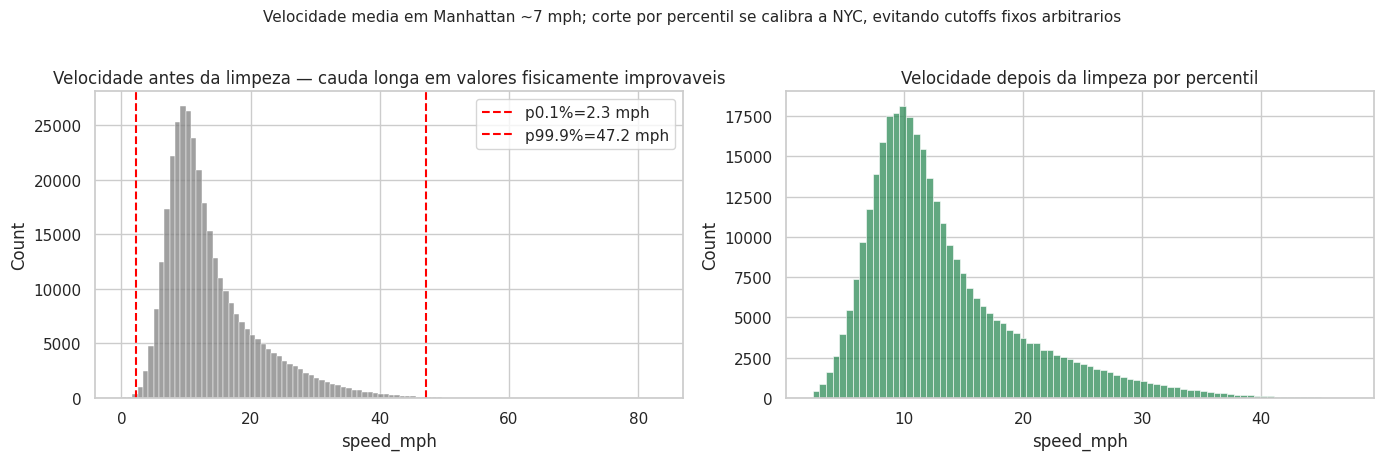

In [8]:

# Distribuicao da velocidade calculada (antes vs depois da limpeza)
speed_before_pdf = spark.sql("""
SELECT trip_length / (total_ride_time / 3600.0) AS speed_mph
FROM trips_raw TABLESAMPLE (0.3 PERCENT)
WHERE total_ride_time > 60 AND trip_length > 0
""").toPandas()
speed_before_pdf = speed_before_pdf[speed_before_pdf['speed_mph'].between(0, 150)]
speed_after_pdf = spark.sql("""
SELECT speed_mph FROM trips_clean TABLESAMPLE (0.3 PERCENT)
""").toPandas()

bounds = spark.sql('SELECT speed_low, speed_high FROM cleaning_bounds').collect()[0].asDict()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(speed_before_pdf['speed_mph'], bins=100, ax=axes[0], color='gray')
axes[0].axvline(bounds['speed_low'], color='red', linestyle='--',
                label=f"p0.1%={bounds['speed_low']:.1f} mph")
axes[0].axvline(bounds['speed_high'], color='red', linestyle='--',
                label=f"p99.9%={bounds['speed_high']:.1f} mph")
axes[0].set_title('Velocidade antes da limpeza — cauda longa em valores fisicamente improvaveis')
axes[0].set_xlabel('speed_mph')
axes[0].legend()

sns.histplot(speed_after_pdf['speed_mph'], bins=80, ax=axes[1], color='seagreen')
axes[1].set_title('Velocidade depois da limpeza por percentil')
axes[1].set_xlabel('speed_mph')

fig.suptitle('Velocidade media em Manhattan ~7 mph; corte por percentil se calibra a NYC, evitando cutoffs fixos arbitrarios',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


In [9]:
# DQ gate: mais de 20% de linhas removidas indica problema de calibracao
metrics_row = spark.sql("""
WITH total AS (SELECT COUNT(*) AS n FROM trips_raw),
     clean_total AS (SELECT COUNT(*) AS n FROM trips_clean)
SELECT
    total.n AS raw_count,
    clean_total.n AS clean_count,
    ROUND((total.n - clean_total.n) * 100.0 / total.n, 2) AS drop_pct
FROM total CROSS JOIN clean_total
""").collect()[0].asDict()
print(metrics_row)
assert metrics_row['drop_pct'] < 20, f"DQ gate: {metrics_row['drop_pct']}% removido (limite 20%)"
print('DQ gate OK')


{'raw_count': 116225448, 'clean_count': 110116813, 'drop_pct': Decimal('5.26')}
DQ gate OK


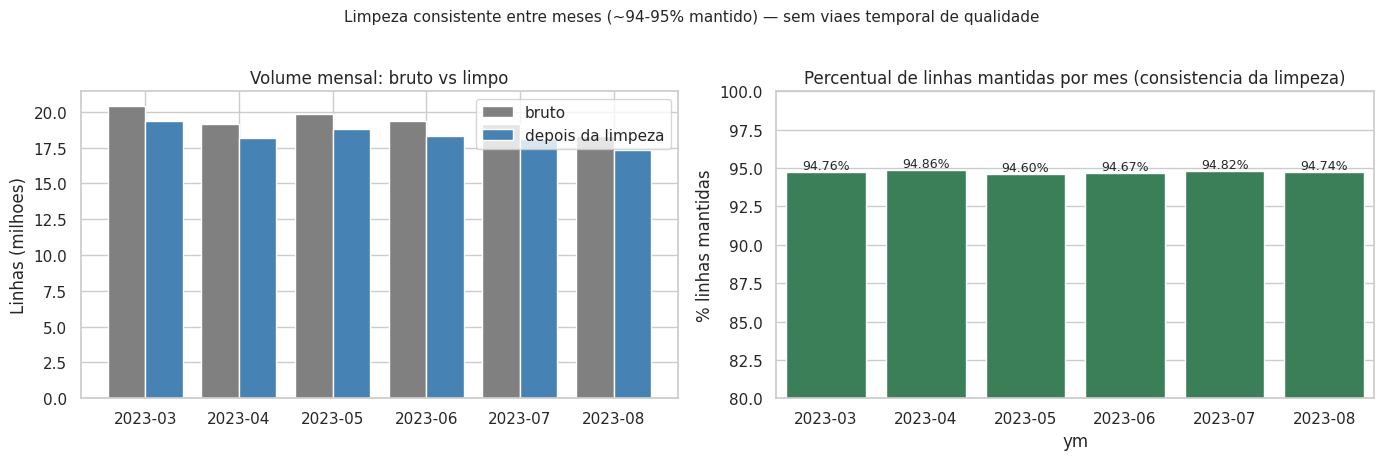

In [10]:

# Volume mensal apos limpeza (eixo Y) e percentual mantido (texto)
monthly_pdf = spark.sql("""
WITH raw_per_month AS (
    SELECT DATE_FORMAT(date, 'yyyy-MM') AS ym, COUNT(*) AS raw_n
    FROM trips_raw GROUP BY 1
), clean_per_month AS (
    SELECT DATE_FORMAT(date, 'yyyy-MM') AS ym, COUNT(*) AS clean_n
    FROM trips_clean GROUP BY 1
)
SELECT r.ym, r.raw_n, c.clean_n,
       ROUND(c.clean_n * 100.0 / r.raw_n, 2) AS kept_pct
FROM raw_per_month r JOIN clean_per_month c USING (ym)
ORDER BY r.ym
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = range(len(monthly_pdf))
axes[0].bar([i - 0.2 for i in x], monthly_pdf['raw_n'] / 1e6, width=0.4,
            label='bruto', color='gray')
axes[0].bar([i + 0.2 for i in x], monthly_pdf['clean_n'] / 1e6, width=0.4,
            label='depois da limpeza', color='steelblue')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(monthly_pdf['ym'])
axes[0].set_ylabel('Linhas (milhoes)')
axes[0].set_title('Volume mensal: bruto vs limpo')
axes[0].legend()

sns.barplot(data=monthly_pdf, x='ym', y='kept_pct', ax=axes[1], color='seagreen')
axes[1].set_ylim(80, 100)
axes[1].set_ylabel('% linhas mantidas')
axes[1].set_title('Percentual de linhas mantidas por mes (consistencia da limpeza)')
for i, row in monthly_pdf.iterrows():
    axes[1].text(i, row['kept_pct'], f"{row['kept_pct']}%", ha='center', va='bottom', fontsize=9)

fig.suptitle('Limpeza consistente entre meses (~94-95% mantido) — sem viaes temporal de qualidade',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


In [11]:
# Materializa o dataset preparado em Parquet particionado por mes para leitura eficiente nos modelos
(spark.table('trips_clean')
    .repartition('pickup_year_month')
    .write
    .partitionBy('pickup_year_month')
    .mode('overwrite')
    .parquet(CLEAN_DATA_PATH))
print(f'Dataset preparado escrito em {CLEAN_DATA_PATH}')


Dataset preparado escrito em /data/silver/trips_silver


In [12]:
spark.read.parquet(CLEAN_DATA_PATH).createOrReplaceTempView('trips_clean_disk')
spark.sql("""
SELECT pickup_year_month, COUNT(*) AS trips
FROM trips_clean_disk
GROUP BY 1 ORDER BY 1
""").show(100, truncate=False)


+-----------------+--------+
|pickup_year_month|trips   |
+-----------------+--------+
|2023-03          |19345807|
|2023-04          |18159527|
|2023-05          |18777076|
|2023-06          |18336484|
|2023-07          |18140472|
|2023-08          |17357447|
+-----------------+--------+



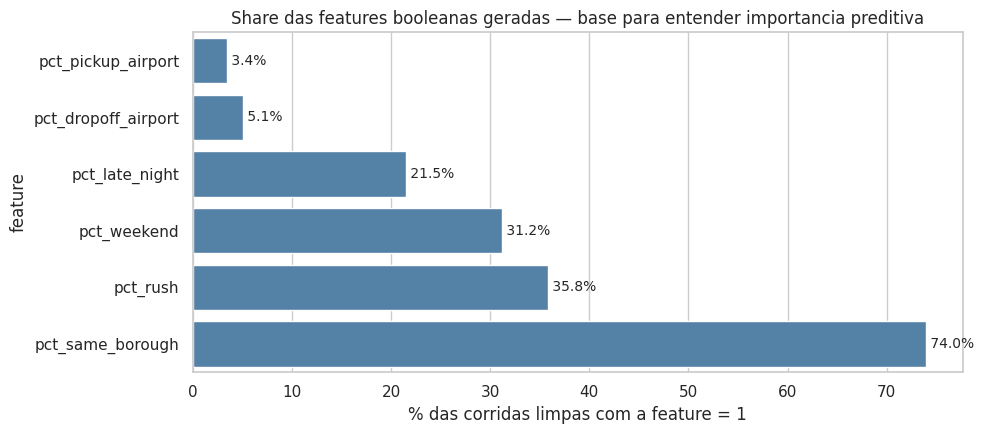

In [13]:

# Composicao das features booleanas geradas (visualizacao de share)
feat_pdf = spark.sql("""
SELECT
    AVG(is_weekend)      AS pct_weekend,
    AVG(is_rush_hour)    AS pct_rush,
    AVG(is_late_night)   AS pct_late_night,
    AVG(pickup_airport)  AS pct_pickup_airport,
    AVG(dropoff_airport) AS pct_dropoff_airport,
    AVG(same_borough)    AS pct_same_borough
FROM trips_clean
""").toPandas().T.reset_index()
feat_pdf.columns = ['feature', 'share']
feat_pdf['share_pct'] = feat_pdf['share'] * 100
feat_pdf = feat_pdf.sort_values('share_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=feat_pdf, y='feature', x='share_pct', ax=ax, color='steelblue', orient='h')
for i, row in enumerate(feat_pdf.itertuples()):
    ax.text(row.share_pct, i, f' {row.share_pct:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% das corridas limpas com a feature = 1')
ax.set_title('Share das features booleanas geradas — base para entender importancia preditiva')
fig.tight_layout()
plt.show()


In [14]:
spark.stop()
